In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.shape

(1000, 8)

In [9]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [12]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [13]:
numeric_features=[feature for feature in df.columns if df[feature].dtype!='O']
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O']

In [17]:
print('number of numerical features is {} and names: {}'.format(len(numeric_features),numeric_features))

number of numerical features is 3 and names: ['math_score', 'reading_score', 'writing_score']


In [18]:
print('number of categorical features is {} and names :{}'.format(len(categorical_features),categorical_features))

number of categorical features is 5 and names :['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [19]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [20]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['average_score']=df['total_score']/3

In [21]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [22]:
df.dropc(['math_score','reading_score','writing_score'])

KeyError: "['math_score', 'reading_score', 'writing_score'] not found in axis"

In [23]:
df.drop(columns=['math_score','reading_score','writing_score'],axis=1,inplace=True)

In [24]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,total_score,average_score
0,female,group B,bachelor's degree,standard,none,218,72.666667
1,female,group C,some college,standard,completed,247,82.333333
2,female,group B,master's degree,standard,none,278,92.666667
3,male,group A,associate's degree,free/reduced,none,148,49.333333
4,male,group C,some college,standard,none,229,76.333333


In [29]:
df[df['average_score']<30]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,total_score,average_score
17,female,group B,some high school,free/reduced,none,78,26.000000
59,female,group C,some high school,free/reduced,none,27,9.000000
76,male,group E,some high school,standard,none,78,26.000000
327,male,group A,some college,free/reduced,none,70,23.333333
338,female,group B,some high school,free/reduced,none,89,29.666667
596,male,group B,high school,free/reduced,none,69,23.000000
601,female,group C,high school,standard,none,88,29.333333
787,female,group B,some college,standard,none,89,29.666667
980,female,group B,high school,free/reduced,none,55,18.333333


In [30]:
passed_students=df[df['total_score']<90].count()


In [31]:
passed_students




gender                         9
race_ethnicity                 9
parental_level_of_education    9
lunch                          9
test_preparation_course        9
total_score                    9
average_score                  9
dtype: int64

<Axes: xlabel='total_score', ylabel='gender'>

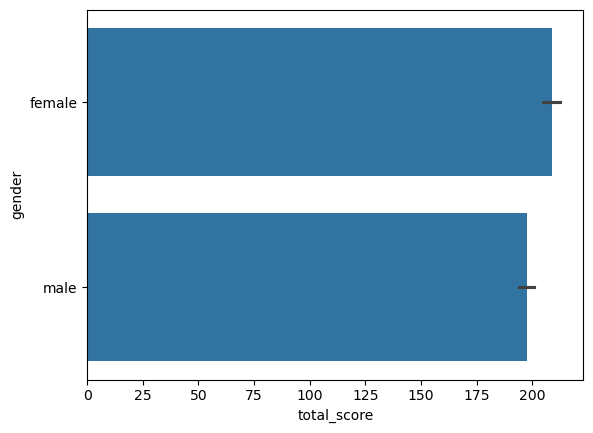

In [32]:
sns.barplot(x=df['total_score'],y=df['gender'])

<Axes: xlabel='total_score', ylabel='gender'>

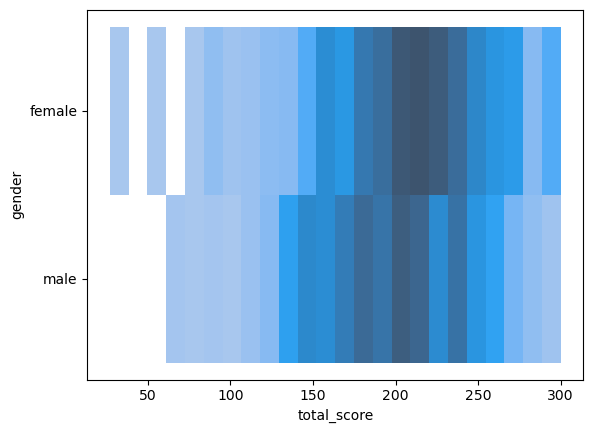

In [33]:
sns.histplot(x=df['total_score'],y=df['gender'])

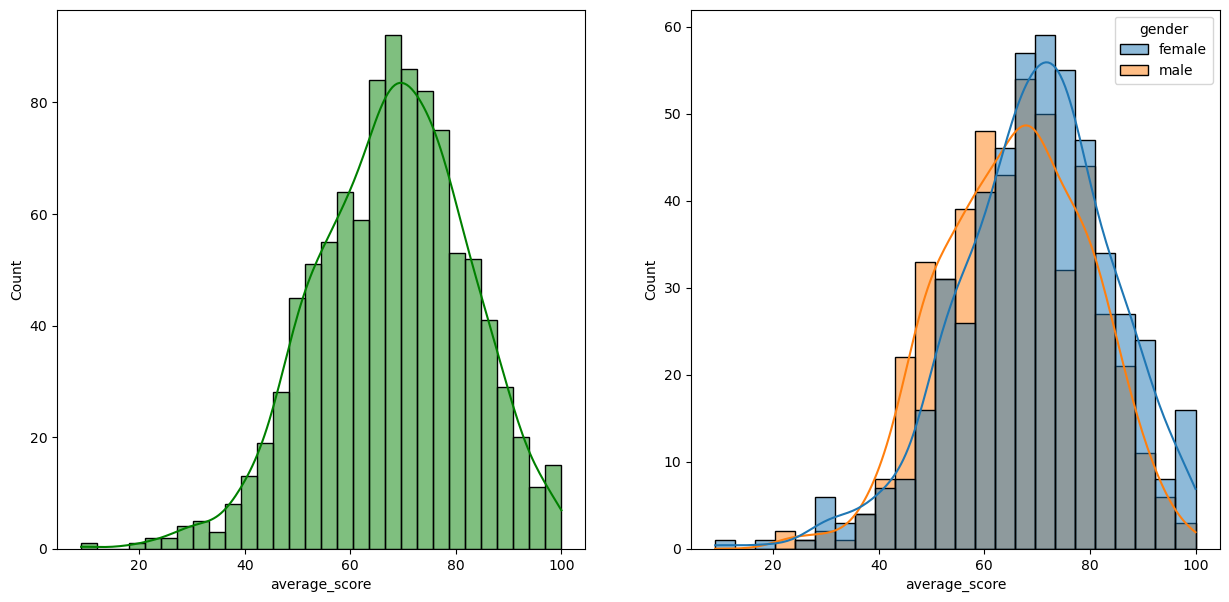

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.show()

<Axes: xlabel='average_score', ylabel='Count'>

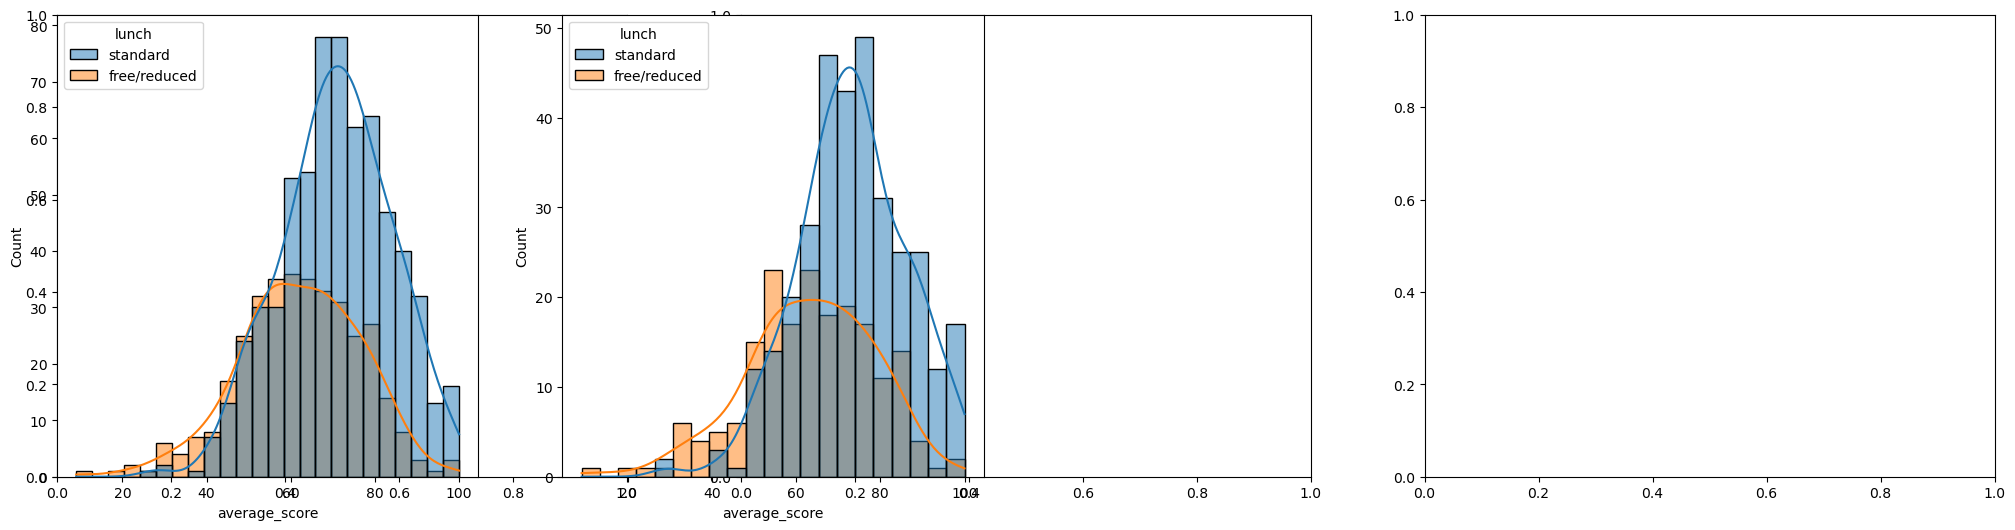

In [36]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average_score',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True,hue='lunch')